# Exercise 1 — Data Mining vs Machine Learning

What you will learn here:

* distinguish data vs labels
* think about problem formulation
* connect real data → ML type
* understand when ML is needed

In [ ]:
# If needed:
!pip install datasets pandas matplotlib scikit-learn librosa

In [2]:
from datasets import load_dataset
import pandas as pd

/home/khoi/Desktop/Lecture/B2/ml-course/docs/1-Introduction-to-Machine-Learning-and-Data-Mining/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load a small sample from the `ag_news` dataset and is a collection of more than 1 million news articles.

In [11]:
dataset = load_dataset("ag_news", split="train[:200]")

df = dataset.to_pandas()
df.head()

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2


### Understand the dataset

In [12]:
df.columns

Index(['text', 'label'], dtype='str')

In [8]:
df[["text", "label"]].head(10)

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,2
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2
3,Iraq Halts Oil Exports from Main Southern Pipe...,2
4,"Oil prices soar to all-time record, posing new...",2
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",2
6,Money Funds Fell in Latest Week (AP) AP - Asse...,2
7,Fed minutes show dissent over inflation (USATO...,2
8,Safety Net (Forbes.com) Forbes.com - After ear...,2
9,Wall St. Bears Claw Back Into the Black NEW Y...,2


## Question
What are the columns?

- Which column is the input data?
- Which column is the label?

Answer:
- Column is specified by each label
- The column "text" is the input data
- The column "label" is the label

# Part A — Data Mining: Discover patterns

For this step, you cannot use the `label` column. :)

### Text length

In [ ]:
df["text_length"] = df["text"].apply(len)

df[["text", "text_length"]].head()

### Average text length

In [7]:
df["text_length"].mean()

np.float64(277.225)

### Most frequent words

In [ ]:
from collections import Counter
import re

all_text = " ".join(df["text"].tolist()).lower()
words = re.findall(r"\b[a-z]{4,}\b", all_text)

word_counts = Counter(words)
word_counts.most_common(20)

## Reflection

Are we predicting something here?

Or are we discovering patterns already present in the data?

Answer:
- No, we aren't
- Yes, all of the data is already exist

# Part B — Machine Learning: Use labels

### Inspect labels

In [9]:
df["label"].value_counts()

label
3    122
2     78
Name: count, dtype: int64

### AG News labels are numeric. Add names:
from https://huggingface.co/datasets/sh0416/ag_news 

1: World 2: Sports 3: Business 4: Sci/Tech

In [ ]:
label_names = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

df["label_name"] = df["label"].map(label_names)
df[["text", "label", "label_name"]].head()

## Question

What type of ML can we apply for this dataset?

Answer:
- We apply classification of supervised

# Part C — Explore a Dataset

In this exercise, you will:

1. Choose a dataset
2. Explore it (Data Mining)
3. Decide whether labels exist
4. Suggest a Machine Learning approach (if applicable)

You should NOT focus on complex models.
Focus on understanding the problem.

## Step 1 — Choose a dataset

* Hugging Face datasets: https://huggingface.co/datasets
* Scikit-learn datasets: https://scikit-learn.org/stable/datasets/toy_dataset.html

Dataset examples:

In [17]:
dataset = load_dataset("cats_vs_dogs", split="train[:10]")

df = dataset.to_pandas()
df.head()

,image,labels
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


- What type of data is this? tabular: display the bytes of the images
- Does this dataset contain labels? Yes — column labels
- What are they? 0 = cat, 1 = dog
- This is Supervised Learning because each image has a clear label
- More specifically: Classification
- Input (X): an image of an animal
- Output (y): 0 or 1 (cat or dog)
- Goal: Classify whether an image is a cat or a dog

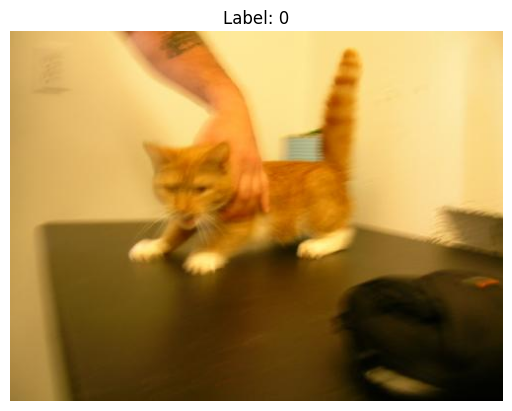

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

# Get one example
example = dataset[0]

# Load image
image = example["image"]

# Display
plt.imshow(image)
plt.title(f"Label: {example['labels']}")
plt.axis("off")
plt.show()

In [20]:
from datasets import load_dataset

dataset = load_dataset("nelorth/oxford-flowers", split="train[:100]")

df = dataset.to_pandas()
df.head()

Generating test split: 100%|██████████| 1020/1020 [00:00<00:00, 8829.37 examples/s]


,image,label
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0


- What type of data is this? Image data: each row contains an image stored as bytes and a numeric label
- Does this dataset contain labels? Yes — column label
- What are they? Numbers from 0 to 101 representing different flower species
- This is Supervised Learning because each image has a clear label
- More specifically: Multi-class Classification
- Input (X): an image of a flower
- Output (y): a number (0–101) representing the flower species
- Goal: Classify which species of flower is in the image

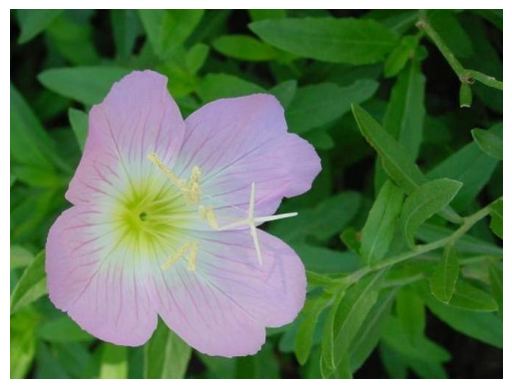

In [21]:
# Get one example
example = dataset[1]

# Load image
image = example["image"]

# Display
plt.imshow(image)
# plt.title(f"Label: {example['labels']}")
plt.axis("off")
plt.show()

In [4]:
from sklearn.datasets import load_wine
import pandas as pd

data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)
df["label"] = data.target
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,label
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [3]:
dataset = load_dataset("glue", "sst2", split="train[:10]")

df = dataset.to_pandas()
df.head()

Generating test split: 100%|██████████| 1821/1821 [00:00<00:00, 206919.91 examples/s]


,sentence,label,idx
0,hide new secretions from the parental units,0,0
1,"contains no wit , only labored gags",0,1
2,that loves its characters and communicates som...,1,2
3,remains utterly satisfied to remain the same t...,0,3
4,on the worst revenge-of-the-nerds clichés the ...,0,4


In [25]:
import numpy as np
import pandas as pd

df = pd.DataFrame({
    "age": np.random.randint(18, 70, 50),
    "income": np.random.randint(1000, 5000, 50),
    "spending": np.random.randint(100, 2000, 50)
})

df.head()

,age,income,spending
0,49,3463,209
1,23,3004,193
2,52,3120,1052
3,69,3929,1815
4,57,2192,592


In [90]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train[:200]")
df = dataset.to_pandas()
df.head()

README.md: 0.00B [00:00, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

wikitext-2-raw-v1/validation-00000-of-00(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

,text
0,
1,= Valkyria Chronicles III = \n
2,
3,Senjō no Valkyria 3 : Unrecorded Chronicles (...
4,"The game began development in 2010 , carrying..."


In [92]:
from datasets import load_dataset

dataset = load_dataset("tweet_eval", "sentiment", split="train[:200]")
df = dataset.to_pandas()

df.head()

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

,text,label
0,"""QT @user In the original draft of the 7th boo...",2
1,"""Ben Smith / Smith (concussion) remains out of...",1
2,Sorry bout the stream last night I crashed out...,1
3,Chase Headley's RBI double in the 8th inning o...,1
4,@user Alciato: Bee will invest 150 million in ...,2


## Step 2 — Explore (Data Mining)

TODO 1: Display a few examples

TODO 2: What type of data is this?
(text, image, tabular)

TODO 3: Find simple patterns

Examples:
- text: most frequent words
- tabular: average values
- images: visualize samples
etc.

## Step 3 — Think about labels

### Questions

1. Does this dataset contain labels?
2. If yes:
   - What are they?
3. If no:
   - What could we try to discover?

## Step 4 — Decide the type of ML

### Identify the problem

- Is this:
  - Data Mining?
  - Supervised Learning?
  - Unsupervised Learning?
  - Reinforcement Learning?

Explain your reasoning.

## Step 5 — Suggest a task

### Your task

Propose ONE task:

- What is the input (X)?
- What is the output (y)? (if any)
- What is the goal?

Examples:
- classify articles
- cluster customers
- extract entities

I wrote the answer below first 2 code of tablar, I had changed to the other dataset too